# Degrees of freedom

The degrees of freedom $\alpha$ control the heaviness of the tails of the
t-SNE kernel

$$k(\mathbf{y}_i, \mathbf{y}_j) = \left( 1 + \frac{\lVert \mathbf{y}_i - \mathbf{y}_j \rVert^2}{\alpha} \right)^{-\alpha},$$

which reduces to the standard t-SNE kernel $(1 + \lVert \mathbf{y}_i - \mathbf{y}_j \rVert^2)^{-1}$ at $\alpha = 1$. Lower values produce heavier
tails that pull apart neighbouring points and expose finer structure, while
larger values give a more Gaussian-like kernel that keeps continuous
structure together. Instead of tuning $\alpha$ by hand, openTSNE can also
*learn* it during optimization with ``dof="auto"``.

We illustrate both the effect of the kernel and the learned value on the
classic *swiss roll*: a two-dimensional sheet rolled up in three
dimensions. It is a continuous manifold rather than a set of clusters, which
makes it a good stress test for the tail heaviness.

In [1]:
from openTSNE import TSNE

import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

## The swiss roll

We sample points from the swiss roll and colour them by their position
`t` along the roll. A good two-dimensional embedding should unroll the
sheet into a smooth rectangle, keeping the colour gradient continuous.

In [2]:
x, t = make_swiss_roll(n_samples=5000, noise=0.05, random_state=42)
print("Data set contains %d samples with %d features" % x.shape)

Data set contains 5000 samples with 3 features


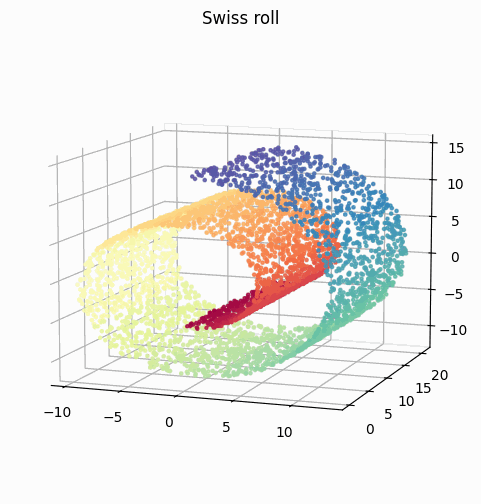

In [3]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x[:, 0], x[:, 1], x[:, 2], c=t, cmap="Spectral", s=5, alpha=0.8)
ax.set_title("Swiss roll")
ax.view_init(10, -70)
plt.show()

A small helper to draw the resulting two-dimensional embeddings, keeping
the same colour map throughout. By default it colours by the full ``t``
vector, but a different colour array can be passed for subsets of points.

In [4]:
def plot(embedding, c=None, ax=None, title=None):
    if c is None:
        c = t
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(embedding[:, 0], embedding[:, 1], c=c, cmap="Spectral", s=3, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

## Standard t-SNE

By default the degrees of freedom are fixed at `dof=1`, recovering ordinary
t-SNE. The `dof_` attribute always records the value that was actually used.

In [5]:
embedding_standard = TSNE(dof=1, random_state=42).fit(x)
embedding_standard.dof_

1

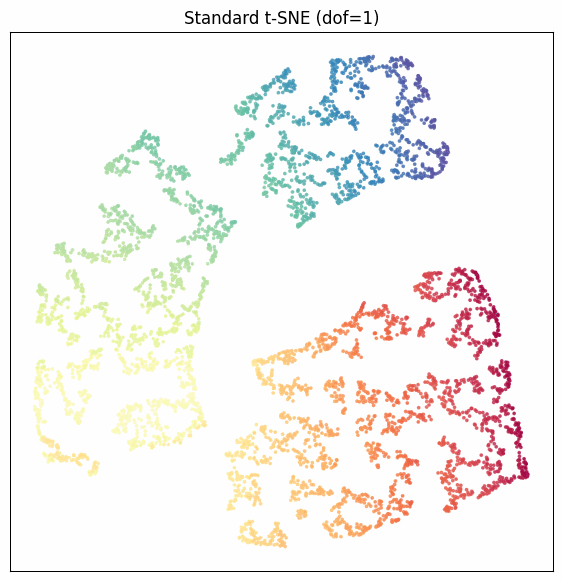

In [6]:
plot(embedding_standard, title="Standard t-SNE (dof=1)")
plt.show()

## A heavier-tailed kernel

Lowering `dof` makes the tails heavier. On clustered data this helps to
separate clusters, but on a continuous manifold it tends to tear the sheet
apart, breaking the smooth colour gradient into fragments.

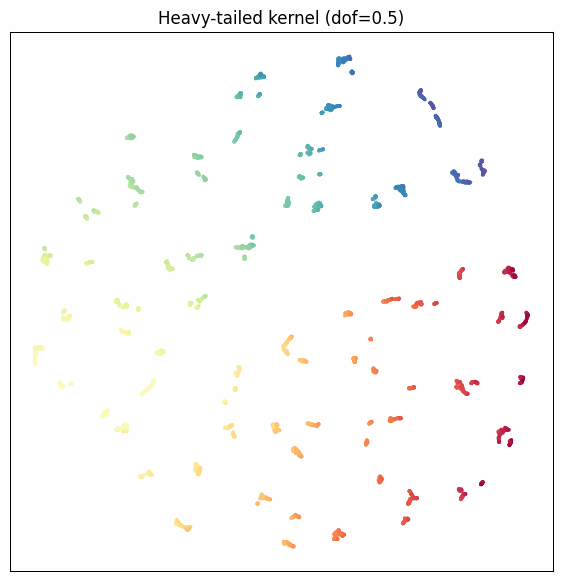

In [7]:
embedding_heavy = TSNE(dof=0.5, random_state=42).fit(x)
plot(embedding_heavy, title="Heavy-tailed kernel (dof=0.5)")
plt.show()

## Learning the degrees of freedom

Rather than guessing a value, we can let openTSNE learn it by passing
`dof="auto"`. Learning is performed with the Barnes-Hut gradient, which is
selected automatically for low-dimensional embeddings. The learned value is
written to `dof_` once optimization finishes.

In [8]:
embedding_auto = TSNE(dof="auto", random_state=42).fit(x)
embedding_auto.dof_

5.02806211364365

For the swiss roll the optimizer settles on a fairly large value, i.e. a
light-tailed, more Gaussian-like kernel. This is the opposite of what one
would want for clustered data, and reflects the fact that the swiss roll is
a single connected manifold that should stay together rather than fragment.

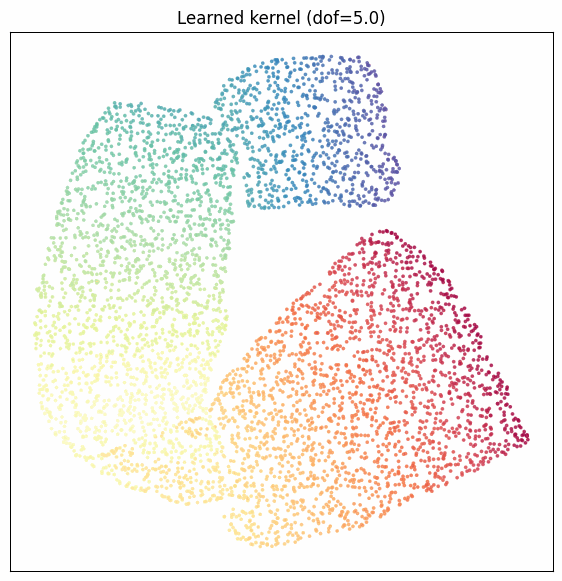

In [9]:
plot(embedding_auto, title=f"Learned kernel (dof={embedding_auto.dof_:.1f})")
plt.show()

## Side by side

Placing the three embeddings next to each other shows the progression from
a fragmented heavy-tailed embedding, through standard t-SNE, to the smooth
unrolled sheet recovered with the learned degrees of freedom.

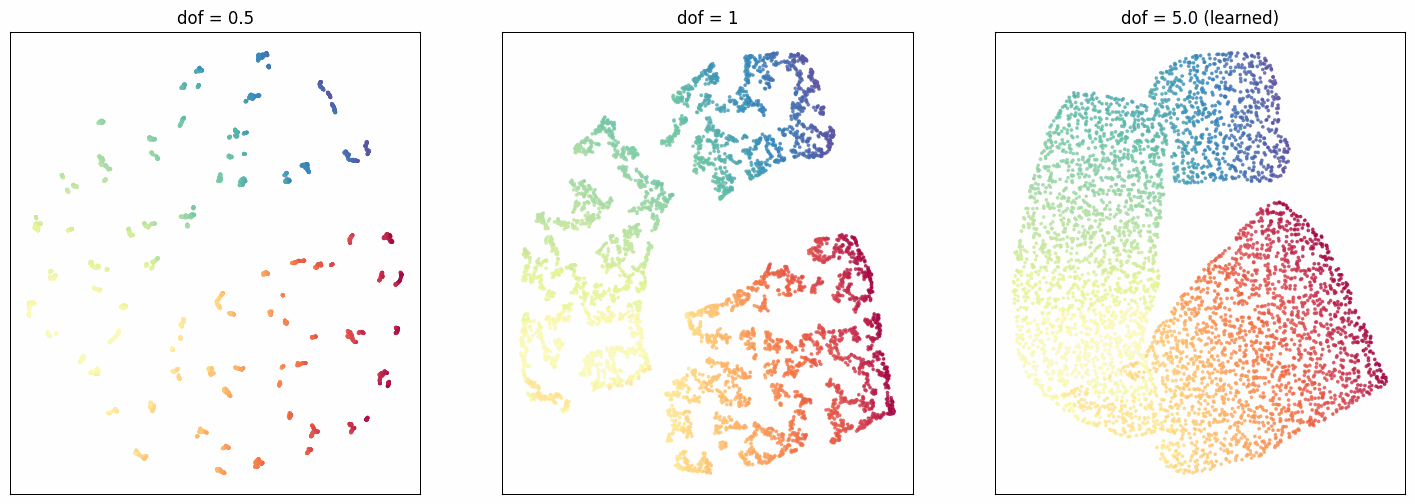

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot(embedding_heavy, ax=axes[0], title="dof = 0.5")
plot(embedding_standard, ax=axes[1], title="dof = 1")
plot(embedding_auto, ax=axes[2], title=f"dof = {embedding_auto.dof_:.1f} (learned)")
plt.show()

## The advanced API

The estimator above is a convenient wrapper. For finer control, openTSNE
exposes the affinities, the initialization, and the optimizer separately so
that an embedding can be built and optimized in phases. The `dof` mode can
even be varied between phases: here we hold `dof=1` (standard t-SNE) during
early exaggeration, while the broad layout of the manifold forms, and only
switch on learning with `dof="auto"` for the main phase. Passing
`dof="auto"` to a single `optimize` call overrides the embedding's mode for
that call, so dof starts learning from its current value of 1.

In [11]:
from openTSNE import TSNEEmbedding, affinity, initialization

affinities = affinity.PerplexityBasedNN(x, perplexity=30, random_state=42)
init = initialization.pca(x, random_state=42)

# Construct with the default dof=1, i.e. standard t-SNE
embedding = TSNEEmbedding(
    init, affinities, negative_gradient_method="bh", random_state=42
)
print(f"{'initial dof:':>25} {embedding.dof_}")

# Early exaggeration phase, with dof held fixed at 1
embedding = embedding.optimize(250, exaggeration=12)
print(f"{'after early exaggeration:':>25} {embedding.dof_:.3f}")

# Main phase: switch on dof learning
embedding = embedding.optimize(500, dof="auto")
print(f"{'after main optimization:':>25} {embedding.dof_:.3f}")

             initial dof: 1
after early exaggeration: 1.000
 after main optimization: 4.862


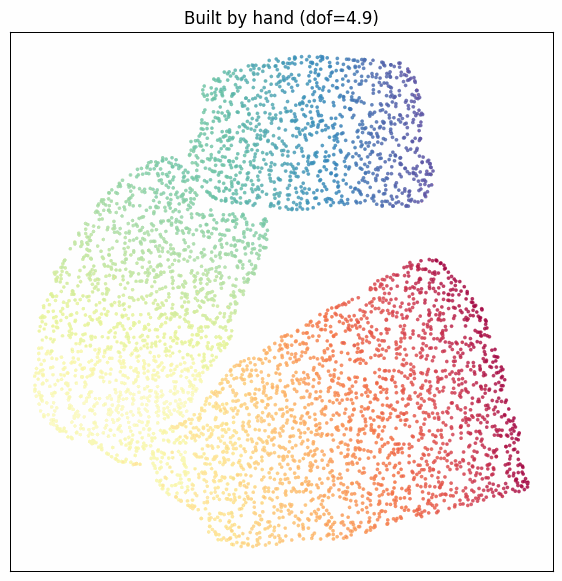

In [12]:
plot(embedding, title=f"Built by hand (dof={embedding.dof_:.1f})")
plt.show()

## Adding new data

openTSNE can embed previously unseen points into an existing embedding with
`transform`. We split the swiss roll into a reference set, which we embed
first, and a set of new points, which we then map into that same space.

In [13]:
x_ref, x_new, t_ref, t_new = train_test_split(
    x, t, test_size=0.33, random_state=42
)

reference = TSNE(dof="auto", random_state=42).fit(x_ref)
reference.dof_

5.397147556833935

By default `transform` uses `dof="inherit"`: the new points adopt the
reference embedding's degrees of freedom and hold them fixed, so they live
in exactly the same kernel as the points they are being mapped against. We
draw the reference embedding faintly and overlay the new points with a black
outline.

In [14]:
new_inherit = reference.transform(x_new)
new_inherit.dof_   # inherits reference.dof_

5.397147556833935

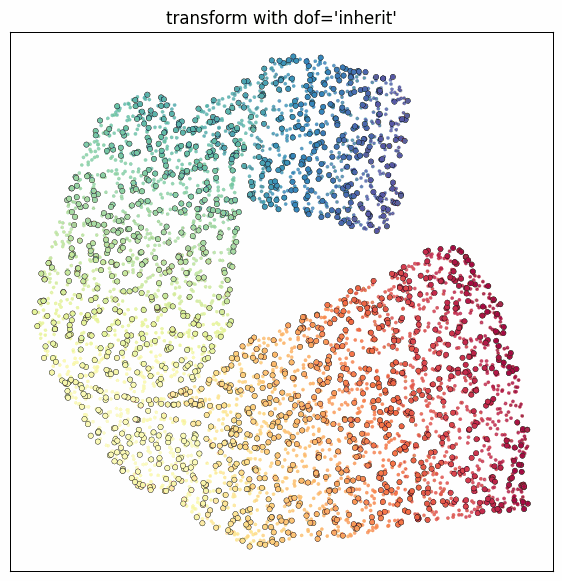

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
plot(reference, c=t_ref, ax=ax)
ax.scatter(
    new_inherit[:, 0], new_inherit[:, 1], c=t_new, cmap="Spectral",
    s=15, edgecolor="k", linewidth=0.3,
)
ax.set_title("transform with dof='inherit'")
plt.show()

The other modes mirror the standard case. Passing `dof="auto"` learns a
separate value for the new points, warm-started from the reference, while a
number pins them to a fixed value regardless of the reference. With the
reference held fixed, though, `dof="auto"` is only weakly identified: the
objective keeps improving slightly as dof grows, so the learned value drifts
upward rather than settling on a clear optimum. For this reason `"inherit"`
is the recommended default for new data. The fixed `dof=1` below deliberately
mismatches the reference kernel, which the comparison makes visible. In all
three cases the embedding itself is barely affected -- the choice of `dof` for
new points changes the learned value far more than where the points land.

In [16]:
new_auto  = reference.transform(x_new, dof="auto")
new_fixed = reference.transform(x_new, dof=1)

print(f"inherit: {new_inherit.dof_:.3f}")
print(f"auto:    {new_auto.dof_:.3f}")
print(f"fixed:   {new_fixed.dof_:.3f}")

/Users/pavlin/Dev/openTSNE/openTSNE/tsne.py:1076: UserWarning: Learning dof for new points (`dof='auto'` on transform / prepare_partial) is uncharted territory: against a fixed reference embedding the objective has no interior optimum in dof, so the learned value drifts upward with more iterations rather than settling. Use at your own risk; `dof='inherit'` (the default) is recommended.
  embedding = self.prepare_partial(


inherit: 5.397
auto:    19.133
fixed:   1.000


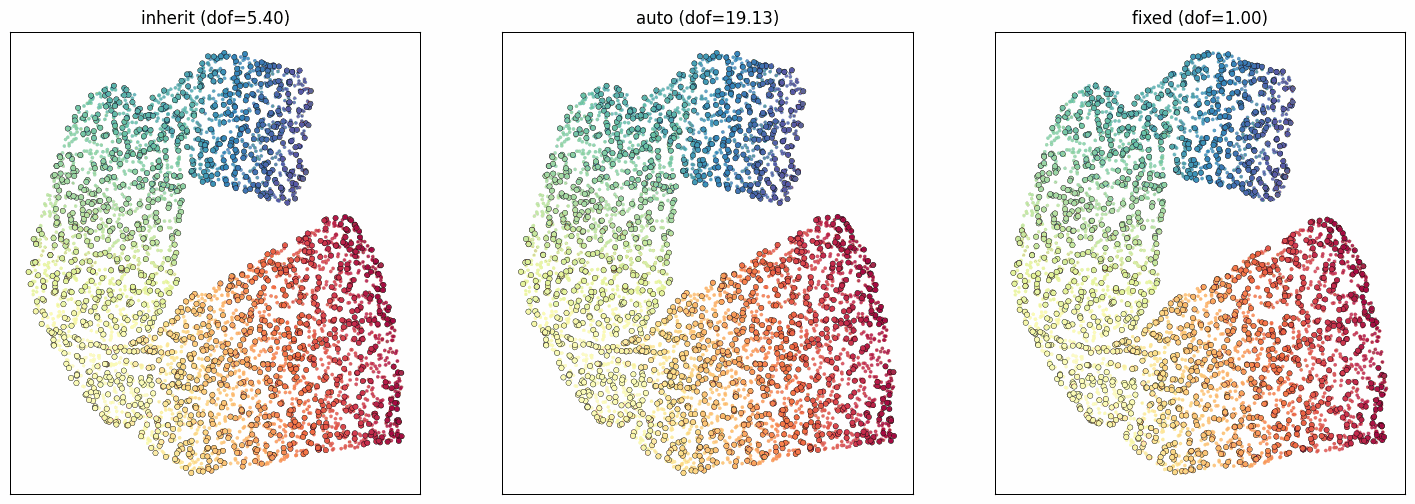

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, emb, title in [
    (axes[0], new_inherit, f"inherit (dof={new_inherit.dof_:.2f})"),
    (axes[1], new_auto, f"auto (dof={new_auto.dof_:.2f})"),
    (axes[2], new_fixed, f"fixed (dof={new_fixed.dof_:.2f})"),
]:
    plot(reference, c=t_ref, ax=ax)
    ax.scatter(
        emb[:, 0], emb[:, 1], c=t_new, cmap="Spectral",
        s=15, edgecolor="k", linewidth=0.3,
    )
    ax.set_title(title)
plt.show()

## A better initialization

Everything above used the default `initialization="pca"`. For the swiss
roll this is a poor starting point: PCA simply projects the three-dimensional
spiral onto the plane of greatest variance, so the embedding *begins* already
rolled up, with layers of the sheet stacked on top of one another. Gradient
descent then has to unfurl the manifold from scratch, and t-SNE's local
objective rarely undoes a global fold like this -- the learned embeddings
above keep distant parts of the colour gradient (blue and red) folded back
against each other.

Spectral initialization instead lays points out using the leading
eigenvectors of the KNN graph, which follow the manifold rather than the
ambient geometry. The embedding therefore *starts* unrolled, and optimization
only has to refine it. We get this by passing `initialization="spectral"`;
the spectral layout is computed directly from the affinity matrix.

In [17]:
embedding_spectral = TSNE(
    initialization="spectral", dof="auto", random_state=0
).fit(x)
embedding_spectral.dof_

29.954301328258545

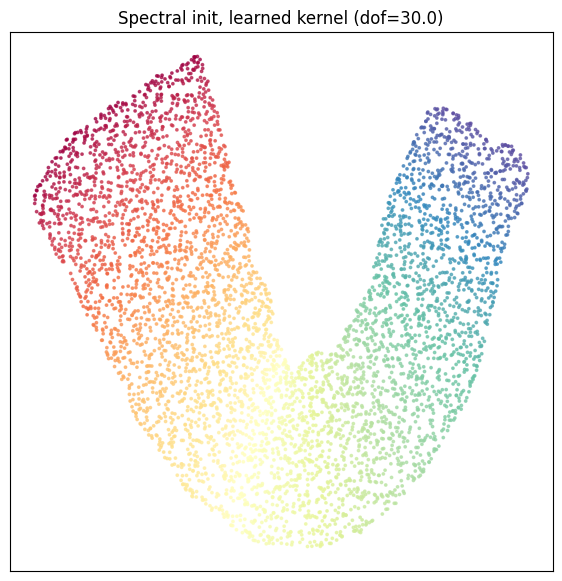

In [18]:
plot(
    embedding_spectral,
    title=f"Spectral init, learned kernel (dof={embedding_spectral.dof_:.1f})",
)
plt.show()

The sheet now unrolls into a single continuous band: the colour gradient runs
smoothly from one end to the other without folding back on itself, in contrast
to the folded PCA-initialized result from earlier. Starting from the unrolled
spectral layout, the optimizer also settles on a much larger, almost Gaussian
`dof` -- light tails that hold the connected manifold together. For a manifold
like the swiss roll, a good initialization matters at least as much as the
kernel, and spectral initialization is the better choice.

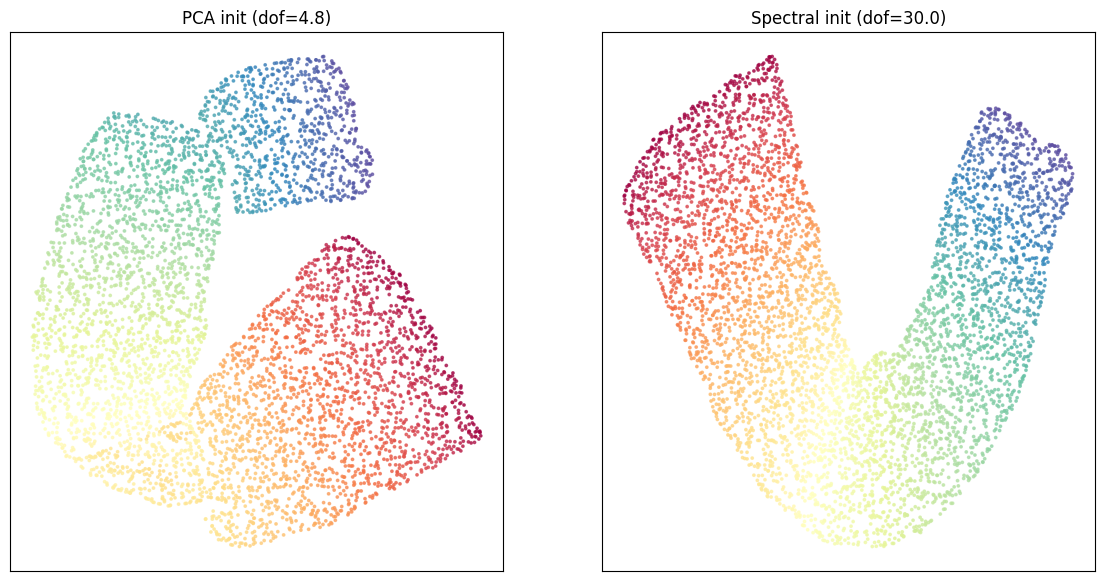

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plot(embedding_auto, ax=axes[0], title=f"PCA init (dof={embedding_auto.dof_:.1f})")
plot(
    embedding_spectral,
    ax=axes[1],
    title=f"Spectral init (dof={embedding_spectral.dof_:.1f})",
)
plt.show()